### DATA EXPLORATION AND UNDERSTANDING

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
from collections import Counter

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [7]:
BASE_DIR = "../data"  

# Image folders
IMG_DIR_1 = os.path.join(BASE_DIR, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(BASE_DIR, "HAM10000_images_part_2")
 
# Metadata
METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata.csv")

for p in [IMG_DIR_1, IMG_DIR_2, METADATA_PATH]:
    status = "FOUND" if os.path.exists(p) else "NOT FOUND"
    print(f"  {status}: {p}")

  FOUND: ../data/HAM10000_images_part_1
  FOUND: ../data/HAM10000_images_part_2
  FOUND: ../data/HAM10000_metadata.csv


#### LOAD AND EXPLORE METADATA

In [8]:
df = pd.read_csv(METADATA_PATH)
 
print("=" * 60)
print("METADATA OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

METADATA OVERVIEW

Shape: 10015 rows x 7 columns

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [9]:
print("=" * 60)
print("COLUMN DETAILS")
print("=" * 60)
 
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

COLUMN DETAILS

Data types:
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Unique values per column:
  lesion_id: 7470 unique values
  image_id: 10015 unique values
  dx: 7 unique values
  dx_type: 4 unique values
  age: 18 unique values
  sex: 3 unique values
  localization: 15 unique values


In [ ]:
CLASS_NAMES = {
    'nv':    'Melanocytic nevi',
    'mel':   'Melanoma',
    'bkl':   'Benign keratosis',
    'bcc':   'Basal cell carcinoma',
    'akiec': 'Actinic keratosis',
    'vasc':  'Vascular lesions',
    'df':    'Dermatofibroma'
}
 
CLASS_TYPE = {
    'nv':    'Benign',
    'mel':   'Malignant',
    'bkl':   'Benign',
    'bcc':   'Malignant',
    'akiec': 'Pre-cancerous',
    'vasc':  'Benign',
    'df':    'Benign'
}

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
 
class_counts = df['dx'].value_counts()

print("\nDiagnosis counts:")
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {cls:6s} ({CLASS_NAMES[cls]:25s}) : {count:5d} images ({pct:.1f}%) [{CLASS_TYPE[cls]}]")
 
print(f"\n  Total: {len(df)} images")
print(f"  Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x")

CLASS DISTRIBUTION
<class 'pandas.core.series.Series'>

Diagnosis counts:
  nv     (Melanocytic nevi         ) :  6705 images (66.9%) [Benign]
  mel    (Melanoma                 ) :  1113 images (11.1%) [Malignant]
  bkl    (Benign keratosis         ) :  1099 images (11.0%) [Benign]
  bcc    (Basal cell carcinoma     ) :   514 images (5.1%) [Malignant]
  akiec  (Actinic keratosis        ) :   327 images (3.3%) [Pre-cancerous]
  vasc   (Vascular lesions         ) :   142 images (1.4%) [Benign]
  df     (Dermatofibroma           ) :   115 images (1.1%) [Benign]

  Total: 10015 images
  Imbalance ratio (max/min): 58.3x


#### VISUALIZE CLASS DISTRIBUTION

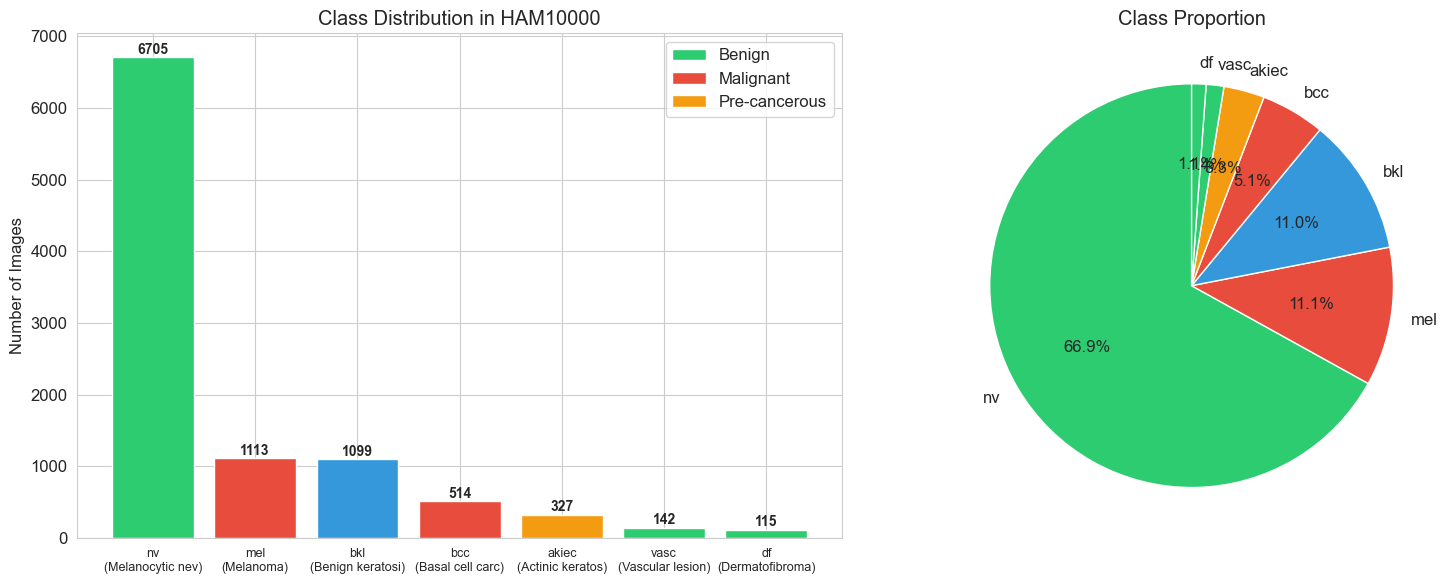

Saved: ../outputs/stage1_class_distribution.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Bar chart
colors = ['#2ECC71', '#E74C3C', '#3498DB', '#E74C3C', '#F39C12', '#2ECC71', '#2ECC71']
order = class_counts.index.tolist()
 
ax1 = axes[0]
bars = ax1.bar(range(len(order)), [class_counts[c] for c in order], color=colors)
ax1.set_xticks(range(len(order)))
ax1.set_xticklabels([f"{c}\n({CLASS_NAMES[c][:15]})" for c in order], fontsize=9)
ax1.set_ylabel("Number of Images")
ax1.set_title("Class Distribution in HAM10000")
 
# Add count labels on bars
for bar, count in zip(bars, [class_counts[c] for c in order]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=10, fontweight='bold')
 
# Add legend for bar colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', label='Benign'),
    Patch(facecolor='#E74C3C', label='Malignant'),
    Patch(facecolor='#F39C12', label='Pre-cancerous')
]
ax1.legend(handles=legend_elements, loc='upper right')
 
# Pie chart
ax2 = axes[1]
ax2.pie(class_counts.values, labels=class_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title("Class Proportion")
 
plt.tight_layout()
# plt.savefig("../outputs/stage1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved: ../outputs/stage1_class_distribution.png")

#### BUILD IMAGE PATH MAPPING

In [15]:
image_paths_1 = glob(os.path.join(IMG_DIR_1, "*.jpg"))
image_paths_2 = glob(os.path.join(IMG_DIR_2, "*.jpg"))
all_image_paths = image_paths_1 + image_paths_2
 
print(f"\nImages found in part_1: {len(image_paths_1)}")
print(f"Images found in part_2: {len(image_paths_2)}")
print(f"Total images found:     {len(all_image_paths)}")
 
# Create a dictionary: image_id -> full_path
image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}
 
# Add image paths to dataframe
df['image_path'] = df['image_id'].map(image_path_dict)
 
# Check for missing images
missing = df['image_path'].isnull().sum()
print(f"Images in metadata but not found on disk: {missing}")
 
if missing > 0:
    print("WARNING: Some images are missing! Check your download.")
else:
    print("All metadata entries have matching image files.")


Images found in part_1: 5000
Images found in part_2: 5015
Total images found:     10015
Images in metadata but not found on disk: 0
All metadata entries have matching image files.


In [16]:
print("\n" + "=" * 60)
print("IMAGE PROPERTIES (sampling 200 images)")
print("=" * 60)
 
sample_paths = np.random.choice(all_image_paths, size=min(200, len(all_image_paths)), replace=False)
 
widths, heights, aspects = [], [], []
for p in sample_paths:
    img = Image.open(p)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    aspects.append(w / h)
 
print(f"  Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"  Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"  Aspect ratio - min: {min(aspects):.2f}, max: {max(aspects):.2f}, mean: {np.mean(aspects):.2f}")
print(f"  Most common size: {Counter(zip(widths, heights)).most_common(1)[0]}")


IMAGE PROPERTIES (sampling 200 images)
  Width  - min: 600, max: 600, mean: 600
  Height - min: 450, max: 450, mean: 450
  Aspect ratio - min: 1.33, max: 1.33, mean: 1.33
  Most common size: ((600, 450), 200)


#### DISPLAY SAMPLE IMAGES FROM EACH CLASS

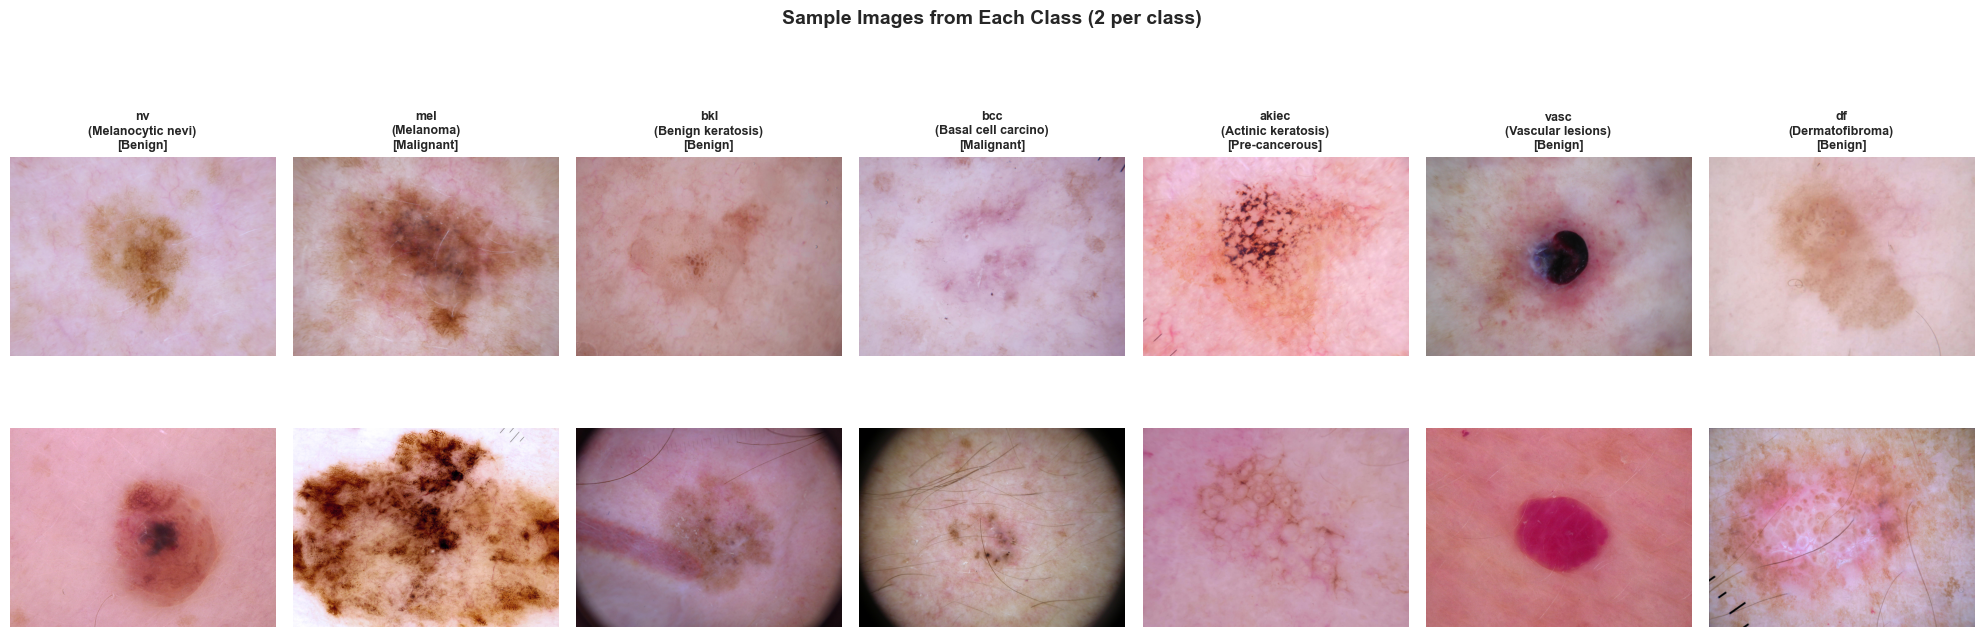

Saved: outputs/stage1_sample_images.png


In [ ]:
fig, axes = plt.subplots(2, 7, figsize=(20, 7))
 
for idx, cls in enumerate(CLASS_NAMES.keys()):
    # Get 2 random images from this class
    cls_images = df[df['dx'] == cls]['image_path'].dropna().values
    samples = np.random.choice(cls_images, size=min(2, len(cls_images)), replace=False)
 
    for row in range(2):
        ax = axes[row][idx]
        img = Image.open(samples[row])
        ax.imshow(img)
        ax.axis('off')
        if row == 0:
            ax.set_title(f"{cls}\n({CLASS_NAMES[cls][:18]})\n[{CLASS_TYPE[cls]}]",
                        fontsize=9, fontweight='bold')
 
plt.suptitle("Sample Images from Each Class (2 per class)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig("../outputs/stage1_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved: outputs/stage1_sample_images.png")

#### PATIENT DEMOGRAPHICS ANALYSIS

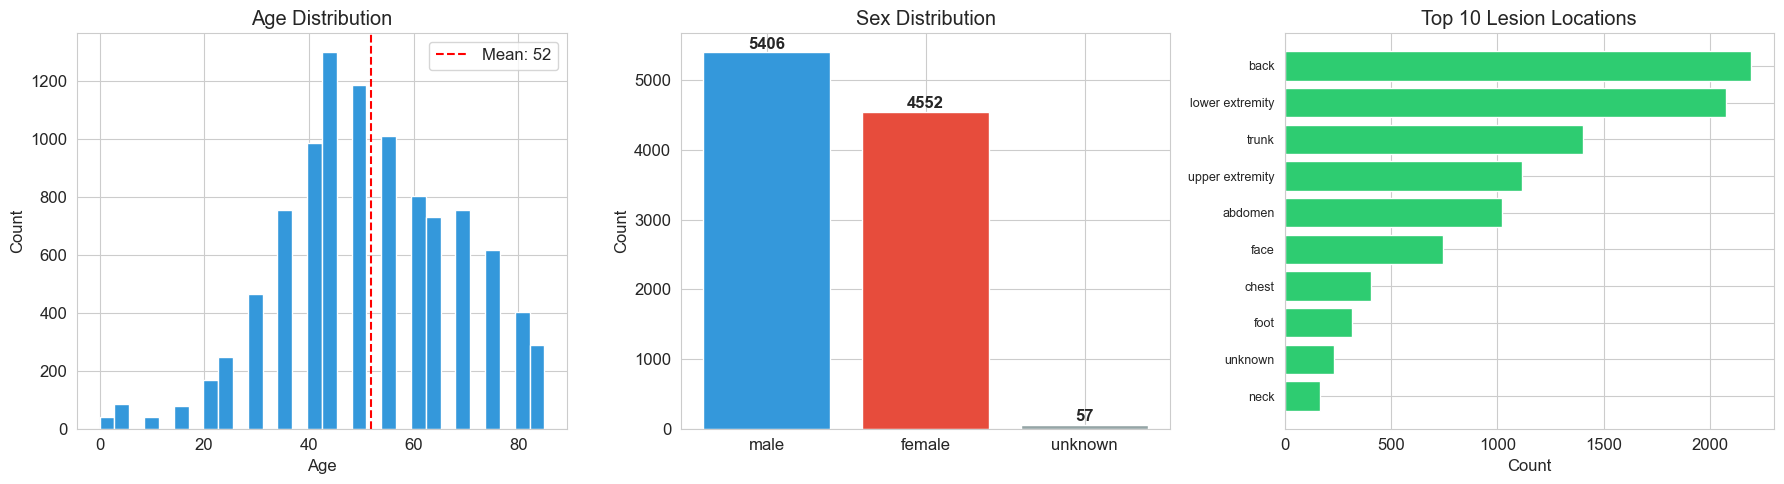

Saved: ../outputs/stage1_demographics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Age distribution
ax1 = axes[0]
df['age'].dropna().hist(bins=30, ax=ax1, color='#3498DB', edgecolor='white')
ax1.set_title("Age Distribution")
ax1.set_xlabel("Age")
ax1.set_ylabel("Count")
ax1.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.0f}")
ax1.legend()
 
# Sex distribution
ax2 = axes[1]
sex_counts = df['sex'].value_counts()
ax2.bar(sex_counts.index, sex_counts.values, color=['#3498DB', '#E74C3C', '#95A5A6'])
ax2.set_title("Sex Distribution")
ax2.set_ylabel("Count")
for i, (s, c) in enumerate(zip(sex_counts.index, sex_counts.values)):
    ax2.text(i, c + 50, str(c), ha='center', fontweight='bold')

# Localization distribution
ax3 = axes[2]
loc_counts = df['localization'].value_counts().head(10)
ax3.barh(range(len(loc_counts)), loc_counts.values, color='#2ECC71')
ax3.set_yticks(range(len(loc_counts)))
ax3.set_yticklabels(loc_counts.index, fontsize=9)
ax3.set_title("Top 10 Lesion Locations")
ax3.set_xlabel("Count")
ax3.invert_yaxis()
 
plt.tight_layout()
# plt.savefig("../outputs/stage1_demographics.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved: ../outputs/stage1_demographics.png")

#### DIAGNOSIS TYPE BREAKDOWN

In [23]:
print("\n" + "=" * 60)
print("DIAGNOSIS CONFIRMATION METHOD (dx_type)")
print("=" * 60)
 
dx_type_counts = df['dx_type'].value_counts()
for dt, count in dx_type_counts.items():
    pct = count / len(df) * 100
    print(f"  {dt:15s}: {count:5d} ({pct:.1f}%)")
 
# Cross-tabulation: dx_type vs dx
print("\nDiagnosis method by class:")
cross_tab = pd.crosstab(df['dx'], df['dx_type'])
print(cross_tab)


DIAGNOSIS CONFIRMATION METHOD (dx_type)
  histo          :  5340 (53.3%)
  follow_up      :  3704 (37.0%)
  consensus      :   902 (9.0%)
  confocal       :    69 (0.7%)

Diagnosis method by class:
dx_type  confocal  consensus  follow_up  histo
dx                                            
akiec           0          0          0    327
bcc             0          0          0    514
bkl            69        264          0    766
df              0         60          0     55
mel             0          0          0   1113
nv              0        503       3704   2498
vasc            0         75          0     67


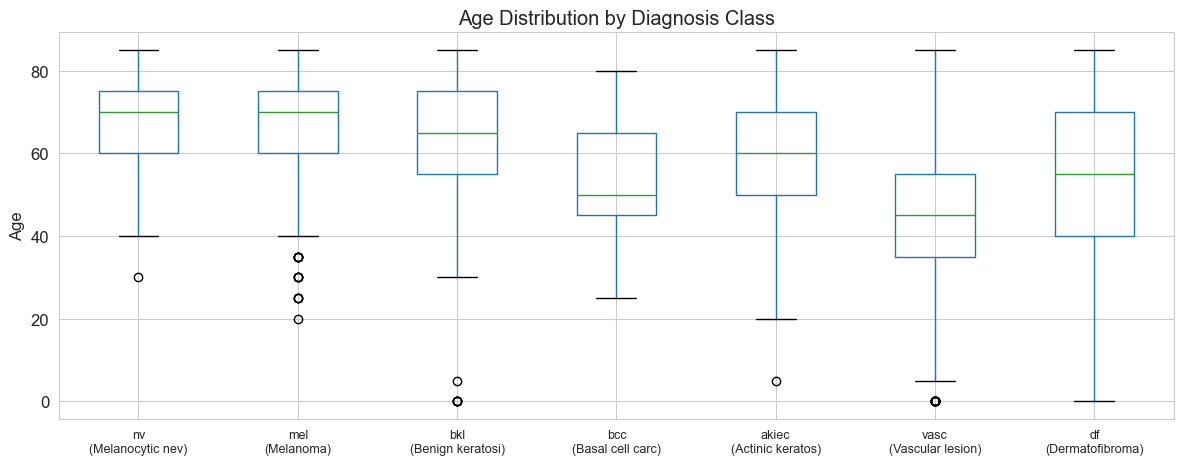

Saved: outputs/stage1_age_by_class.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
class_order = list(CLASS_NAMES.keys())
df.boxplot(column='age', by='dx', ax=ax, positions=range(len(class_order)))
ax.set_xticklabels([f"{c}\n({CLASS_NAMES[c][:15]})" for c in class_order], fontsize=9)
ax.set_title("Age Distribution by Diagnosis Class")
ax.set_xlabel("")
ax.set_ylabel("Age")
plt.suptitle("")  # Remove auto-title from boxplot
plt.tight_layout()
plt.savefig("../outputs/stage1_age_by_class.png", dpi=150, bbox_inches='tight')
plt.show()
 
print("Saved: outputs/stage1_age_by_class.png")

#### DUPLICATE IMAGE CHECK

In [25]:
print("\n" + "=" * 60)
print("DUPLICATE / MULTI-IMAGE LESIONS")
print("=" * 60)
 
print(f"  Unique image_id:  {df['image_id'].nunique()}")
print(f"  Unique lesion_id: {df['lesion_id'].nunique()}")
print(f"  Multiple images per lesion: {df['image_id'].nunique() - df['lesion_id'].nunique()}")
 
dup_lesions = df.groupby('lesion_id').filter(lambda x: len(x) > 1)
print(f"  Images that share a lesion_id with another image: {len(dup_lesions)}")
print(f"\n  NOTE: During train/test split in Stage 2, we will split by")
print(f"  lesion_id (not image_id) to prevent data leakage.")


DUPLICATE / MULTI-IMAGE LESIONS
  Unique image_id:  10015
  Unique lesion_id: 7470
  Multiple images per lesion: 2545
  Images that share a lesion_id with another image: 4501

  NOTE: During train/test split in Stage 2, we will split by
  lesion_id (not image_id) to prevent data leakage.


In [27]:
df.to_csv("../outputs/ham10000_with_paths.csv", index=False)
